In [1]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)

all_files_df_path <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_raw_counts.csv"
all_files_df <- fread(all_files_df_path)

# > head(all_files_df)
# index
# <char>
#   1: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 2: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 3: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 4: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 5: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# 6: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# mode offset count count_scaled    sample condition
# <char> <char> <int>        <int>    <char>    <char>
#   1:  INCLUDED 0:-1:0     1            1 769P-rep1      769P
# 2:  INCLUDED  0:0:0    29           29 769P-rep1      769P
# 3:   SKIPPED      0     3            0 769P-rep1      769P
# 4: UNSPLICED    113     3            0 769P-rep1      769P
# 5:  INCLUDED  0:0:0    88           88 769P-rep1      769P
# 6:   SKIPPED      0    15            1 769P-rep1      769P

# First generate a set of all included events. 
all_files_df <- all_files_df %>% 
  group_by(sample,condition, index) %>%
  mutate(total_counts = sum(count_scaled),
         frac_of_total = count_scaled/total_counts) %>% 
  ungroup() %>% 
  # filter(total_counts >= 30) %>% 
  group_by(sample,condition, index, mode) %>%
  mutate(
    total_counts_per_mode = sum(count_scaled),
    frac_of_mode = count_scaled/sum(count_scaled)) %>% 
  ungroup() 



##### Now generate a set of all possible spliced events. #####
# First get a list of all possible perfect splicing events given all the barcodes. 
barcode_table <- read_csv("/mnt/dawnccle2/melange/data/guide_library_cleaned/20240605_twist_library_v3_ID_barcode_ROUT_filtered.csv")
all_perfect_events <- data.frame(index = barcode_table$ID, mode = "INCLUDED", offset = "0:0:0") %>% as_tibble()

# Imperfect events.
all_possible_imperfect_events <- all_files_df %>%
  filter(mode == "INCLUDED" & offset != "0:0:0" & total_counts_per_mode >= 30) %>% 
  group_by(index, mode, offset) %>% 
  summarise(n = n(), 
            max_perc = max(frac_of_mode), 
            max_reads = max(count_scaled),
            .groups = "drop" ) %>% 
  separate(offset, into = c("skipped_exon_start", "skipped_exon_end", "downstream_exon_start"), sep = ":", remove = FALSE) %>%
  filter(skipped_exon_start < 150 & skipped_exon_end < 150)

all_possible_imperfect_events_filtered <- all_possible_imperfect_events %>% 
  filter(max_reads >= 5 & max_perc > 0.01) %>% 
  select(index, mode, offset)

# All possible included events. 
all_possible_included_events <- rbind(all_perfect_events, all_possible_imperfect_events_filtered) %>% 
  arrange(index, mode, offset) 

# Write the set of all possible included events to a file.
write_csv(all_possible_included_events, "/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_included_events.csv")

# Now also find the set of all possible exon skipping events. This is just the barcode list. 
all_possible_skipped_events <- data.frame(index = barcode_table$ID, mode = "SKIPPED", offset = "0") %>% as_tibble()

# Now also find a set of all possible unspliced events. Probably this doesn't need to use the adjusted reads. 
all_possible_unspliced_events <- all_files_df %>% 
  filter(mode == "UNSPLICED" ) %>% 
  group_by(mode, offset) %>%
  summarise(n = n(), 
            max_perc = max(frac_of_mode, na.rm = T), 
            max_reads = max(count, na.rm = T),
            .groups = "drop" ) %>% 
  mutate(offset = as.integer(offset)) 

####### Now generate a PSI table for each event. #######
# Convert to data.table for faster lookups
all_files_df <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_raw_counts.csv")
setDT(all_files_df)
setDT(all_possible_included_events)

# Create fast lookup tables for INCLUDED and SKIPPED modes
included_lookup <- all_files_df[mode == "INCLUDED", .(count_scaled), keyby = .(sample, index, offset)]
skipped_lookup <- all_files_df[mode == "SKIPPED", .(count_scaled), keyby = .(sample, index)]

# Extract sample-condition pairs
sample_conditions <- unique(all_files_df[, .(sample, condition)])
setDT(sample_conditions)  # Ensure it's a data.table

####### Duplicate Events for Each Sample #######
# Initialize empty list to store duplicated tables
expanded_events_list <- vector("list", length = nrow(sample_conditions))  
# Loop over each sample and duplicate `all_possible_included_events`
for (i in seq_len(nrow(sample_conditions))) {
  sample_name <- sample_conditions$sample[i]
  condition <- sample_conditions$condition[i]
  
  # Duplicate events for this sample
  tmp_events <- copy(all_possible_included_events)
  tmp_events[, sample := sample_name]
  tmp_events[, condition := condition]
  
  # Store in list
  expanded_events_list[[i]] <- tmp_events
}

# Combine all duplicated tables into a single data.table
expanded_events <- rbindlist(expanded_events_list)

####### PSI Computation #######
# Join precomputed tables for efficient count retrieval
final_psi_table <- expanded_events[
  included_lookup, on = .(sample, index, offset), included_count := count_scaled][
    skipped_lookup, on = .(sample, index), skipped_count := count_scaled]

# Replace NAs with 0 (indicating no reads found for an event)
final_psi_table[, c("included_count", "skipped_count") := 
                  lapply(.SD, function(x) fifelse(is.na(x), 0, x)), 
                .SDcols = c("included_count", "skipped_count")]
# Write to file
fwrite(final_psi_table, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table.csv")

# Also filter to sequences that have total reads >= 30. 
final_psi_table_filtered <- final_psi_table %>% 
  mutate(total_reads = included_count + skipped_count) %>%
  filter(total_reads >= 30) 
fwrite(final_psi_table_filtered, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_filtered.csv")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

In [2]:
# MUT now.

all_files_df_path <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_raw_counts.csv"
all_files_df <- fread(all_files_df_path)

# > head(all_files_df)
# index
# <char>
#   1: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 2: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 3: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 4: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 5: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# 6: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# mode offset count count_scaled    sample condition
# <char> <char> <int>        <int>    <char>    <char>
#   1:  INCLUDED 0:-1:0     1            1 769P-rep1      769P
# 2:  INCLUDED  0:0:0    29           29 769P-rep1      769P
# 3:   SKIPPED      0     3            0 769P-rep1      769P
# 4: UNSPLICED    113     3            0 769P-rep1      769P
# 5:  INCLUDED  0:0:0    88           88 769P-rep1      769P
# 6:   SKIPPED      0    15            1 769P-rep1      769P

# First generate a set of all included events. 
all_files_df <- all_files_df %>% 
  group_by(sample,condition, index) %>%
  mutate(total_counts = sum(count_scaled),
         frac_of_total = count_scaled/total_counts) %>% 
  ungroup() %>% 
  # filter(total_counts >= 30) %>% 
  group_by(sample,condition, index, mode) %>%
  mutate(
    total_counts_per_mode = sum(count_scaled),
    frac_of_mode = count_scaled/sum(count_scaled)) %>% 
  ungroup() 



##### Now generate a set of all possible spliced events. #####
# First get a list of all possible perfect splicing events given all the barcodes. 
barcode_table <- read_csv("/mnt/dawnccle2/melange/data/guide_library_cleaned/20240605_twist_library_v3_ID_barcode_ROUT_filtered.csv")
all_perfect_events <- data.frame(index = barcode_table$ID, mode = "INCLUDED", offset = "0:0:0") %>% as_tibble()

# Imperfect events.
all_possible_imperfect_events <- all_files_df %>%
  filter(mode == "INCLUDED" & offset != "0:0:0" & total_counts_per_mode >= 30) %>% 
  group_by(index, mode, offset) %>% 
  summarise(n = n(), 
            max_perc = max(frac_of_mode), 
            max_reads = max(count_scaled),
            .groups = "drop" ) %>% 
  separate(offset, into = c("skipped_exon_start", "skipped_exon_end", "downstream_exon_start"), sep = ":", remove = FALSE) %>%
  filter(skipped_exon_start < 150 & skipped_exon_end < 150)

all_possible_imperfect_events_filtered <- all_possible_imperfect_events %>% 
  filter(max_reads >= 5 & max_perc > 0.01) %>% 
  select(index, mode, offset)

# All possible included events. 
all_possible_included_events <- rbind(all_perfect_events, all_possible_imperfect_events_filtered) %>% 
  arrange(index, mode, offset) 

# Write the set of all possible included events to a file.
write_csv(all_possible_included_events, "/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/MUT_all_included_events.csv")

# Now also find the set of all possible exon skipping events. This is just the barcode list. 
all_possible_skipped_events <- data.frame(index = barcode_table$ID, mode = "SKIPPED", offset = "0") %>% as_tibble()

# Now also find a set of all possible unspliced events. Probably this doesn't need to use the adjusted reads. 
all_possible_unspliced_events <- all_files_df %>% 
  filter(mode == "UNSPLICED" ) %>% 
  group_by(mode, offset) %>%
  summarise(n = n(), 
            max_perc = max(frac_of_mode, na.rm = T), 
            max_reads = max(count, na.rm = T),
            .groups = "drop" ) %>% 
  mutate(offset = as.integer(offset)) 

####### Now generate a PSI table for each event. #######
# Convert to data.table for faster lookups
all_files_df <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_raw_counts.csv")
setDT(all_files_df)
setDT(all_possible_included_events)

# Create fast lookup tables for INCLUDED and SKIPPED modes
included_lookup <- all_files_df[mode == "INCLUDED", .(count_scaled), keyby = .(sample, index, offset)]
skipped_lookup <- all_files_df[mode == "SKIPPED", .(count_scaled), keyby = .(sample, index)]

# Extract sample-condition pairs
sample_conditions <- unique(all_files_df[, .(sample, condition)])
setDT(sample_conditions)  # Ensure it's a data.table

####### Duplicate Events for Each Sample #######
# Initialize empty list to store duplicated tables
expanded_events_list <- vector("list", length = nrow(sample_conditions))  
# Loop over each sample and duplicate `all_possible_included_events`
for (i in seq_len(nrow(sample_conditions))) {
  sample_name <- sample_conditions$sample[i]
  condition <- sample_conditions$condition[i]
  
  # Duplicate events for this sample
  tmp_events <- copy(all_possible_included_events)
  tmp_events[, sample := sample_name]
  tmp_events[, condition := condition]
  
  # Store in list
  expanded_events_list[[i]] <- tmp_events
}

# Combine all duplicated tables into a single data.table
expanded_events <- rbindlist(expanded_events_list)

####### PSI Computation #######
# Join precomputed tables for efficient count retrieval
final_psi_table <- expanded_events[
  included_lookup, on = .(sample, index, offset), included_count := count_scaled][
    skipped_lookup, on = .(sample, index), skipped_count := count_scaled]

# Replace NAs with 0 (indicating no reads found for an event)
final_psi_table[, c("included_count", "skipped_count") := 
                  lapply(.SD, function(x) fifelse(is.na(x), 0, x)), 
                .SDcols = c("included_count", "skipped_count")]
# Write to file
fwrite(final_psi_table, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_PSI_count_table.csv")

# Also filter to sequences that have total reads >= 30. 
final_psi_table_filtered <- final_psi_table %>% 
  mutate(total_reads = included_count + skipped_count) %>%
  filter(total_reads >= 30) 
fwrite(final_psi_table_filtered, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_PSI_count_table_filtered.csv")


Rows: 44648 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): ID, barcode, barcodeRevcomp

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_perc = max(frac_of_mode, na.rm = T)`.
ℹ In group 6: `mode = "UNSPLICED"` `offset = "103"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”


In [3]:
# OEx now.

all_files_df_path <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/OEx_all_samples_raw_counts.csv"
all_files_df <- fread(all_files_df_path)

# > head(all_files_df)
# index
# <char>
#   1: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 2: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 3: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 4: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 5: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# 6: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# mode offset count count_scaled    sample condition
# <char> <char> <int>        <int>    <char>    <char>
#   1:  INCLUDED 0:-1:0     1            1 769P-rep1      769P
# 2:  INCLUDED  0:0:0    29           29 769P-rep1      769P
# 3:   SKIPPED      0     3            0 769P-rep1      769P
# 4: UNSPLICED    113     3            0 769P-rep1      769P
# 5:  INCLUDED  0:0:0    88           88 769P-rep1      769P
# 6:   SKIPPED      0    15            1 769P-rep1      769P

# First generate a set of all included events. 
all_files_df <- all_files_df %>% 
  group_by(sample,condition, index) %>%
  mutate(total_counts = sum(count_scaled),
         frac_of_total = count_scaled/total_counts) %>% 
  ungroup() %>% 
  # filter(total_counts >= 30) %>% 
  group_by(sample,condition, index, mode) %>%
  mutate(
    total_counts_per_mode = sum(count_scaled),
    frac_of_mode = count_scaled/sum(count_scaled)) %>% 
  ungroup() 



##### Now generate a set of all possible spliced events. #####
# First get a list of all possible perfect splicing events given all the barcodes. 
barcode_table <- read_csv("/mnt/dawnccle2/melange/data/guide_library_cleaned/20240605_twist_library_v3_ID_barcode_ROUT_filtered.csv")
all_perfect_events <- data.frame(index = barcode_table$ID, mode = "INCLUDED", offset = "0:0:0") %>% as_tibble()

# Imperfect events.
all_possible_imperfect_events <- all_files_df %>%
  filter(mode == "INCLUDED" & offset != "0:0:0" & total_counts_per_mode >= 30) %>% 
  group_by(index, mode, offset) %>% 
  summarise(n = n(), 
            max_perc = max(frac_of_mode), 
            max_reads = max(count_scaled),
            .groups = "drop" ) %>% 
  separate(offset, into = c("skipped_exon_start", "skipped_exon_end", "downstream_exon_start"), sep = ":", remove = FALSE) %>%
  filter(skipped_exon_start < 150 & skipped_exon_end < 150)

all_possible_imperfect_events_filtered <- all_possible_imperfect_events %>% 
  filter(max_reads >= 5 & max_perc > 0.01) %>% 
  select(index, mode, offset)

# All possible included events. 
all_possible_included_events <- rbind(all_perfect_events, all_possible_imperfect_events_filtered) %>% 
  arrange(index, mode, offset) 

# Write the set of all possible included events to a file.
write_csv(all_possible_included_events, "/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/OEx_all_included_events.csv")

# Now also find the set of all possible exon skipping events. This is just the barcode list. 
all_possible_skipped_events <- data.frame(index = barcode_table$ID, mode = "SKIPPED", offset = "0") %>% as_tibble()

# Now also find a set of all possible unspliced events. Probably this doesn't need to use the adjusted reads. 
all_possible_unspliced_events <- all_files_df %>% 
  filter(mode == "UNSPLICED" ) %>% 
  group_by(mode, offset) %>%
  summarise(n = n(), 
            max_perc = max(frac_of_mode, na.rm = T), 
            max_reads = max(count, na.rm = T),
            .groups = "drop" ) %>% 
  mutate(offset = as.integer(offset)) 

####### Now generate a PSI table for each event. #######
# Convert to data.table for faster lookups
all_files_df <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/OEx_all_samples_raw_counts.csv")
setDT(all_files_df)
setDT(all_possible_included_events)

# Create fast lookup tables for INCLUDED and SKIPPED modes
included_lookup <- all_files_df[mode == "INCLUDED", .(count_scaled), keyby = .(sample, index, offset)]
skipped_lookup <- all_files_df[mode == "SKIPPED", .(count_scaled), keyby = .(sample, index)]

# Extract sample-condition pairs
sample_conditions <- unique(all_files_df[, .(sample, condition)])
setDT(sample_conditions)  # Ensure it's a data.table

####### Duplicate Events for Each Sample #######
# Initialize empty list to store duplicated tables
expanded_events_list <- vector("list", length = nrow(sample_conditions))  
# Loop over each sample and duplicate `all_possible_included_events`
for (i in seq_len(nrow(sample_conditions))) {
  sample_name <- sample_conditions$sample[i]
  condition <- sample_conditions$condition[i]
  
  # Duplicate events for this sample
  tmp_events <- copy(all_possible_included_events)
  tmp_events[, sample := sample_name]
  tmp_events[, condition := condition]
  
  # Store in list
  expanded_events_list[[i]] <- tmp_events
}

# Combine all duplicated tables into a single data.table
expanded_events <- rbindlist(expanded_events_list)

####### PSI Computation #######
# Join precomputed tables for efficient count retrieval
final_psi_table <- expanded_events[
  included_lookup, on = .(sample, index, offset), included_count := count_scaled][
    skipped_lookup, on = .(sample, index), skipped_count := count_scaled]

# Replace NAs with 0 (indicating no reads found for an event)
final_psi_table[, c("included_count", "skipped_count") := 
                  lapply(.SD, function(x) fifelse(is.na(x), 0, x)), 
                .SDcols = c("included_count", "skipped_count")]
# Write to file
fwrite(final_psi_table, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/OEx_all_samples_PSI_count_table.csv")

# Also filter to sequences that have total reads >= 30. 
final_psi_table_filtered <- final_psi_table %>% 
  mutate(total_reads = included_count + skipped_count) %>%
  filter(total_reads >= 30) 
fwrite(final_psi_table_filtered, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/OEx_all_samples_PSI_count_table_filtered.csv")


Rows: 44648 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): ID, barcode, barcodeRevcomp

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There were 8 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_perc = max(frac_of_mode, na.rm = T)`.
ℹ In group 53: `mode = "UNSPLICED"` `offset = "15"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 7 remaining warnings.”


# Do for individual without rep merging

In [1]:
library(tidyverse)
library(vroom)
library(data.table)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

In [55]:
####### Now generate a PSI table for each event. #######
# Convert to data.table for faster lookups
all_files_df <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_raw_counts_individual.csv")
all_possible_included_events <- read_csv("/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_included_events.csv")
setDT(all_files_df)
setDT(all_possible_included_events)


all_files_df <- all_files_df %>% 
  mutate(sample_condition = paste0(sample, "__", condition))
unique_sample_conditions <- unique(all_files_df$sample_condition)


all_possible_included_events <- all_possible_included_events %>% 
mutate(index_offset = paste0(index, "__", offset))

# Expand grid for all_possible_included_events
expanded_events <- expand.grid(index_offset = all_possible_included_events$index_offset, 
                                sample_condition = unique_sample_conditions)


all_files_df_included <- all_files_df %>% 
filter(mode == "INCLUDED") %>% 
mutate(sample_condition = paste0(sample, "__", condition)) %>% 
mutate(index_offset = paste0(index, "__", offset)) %>% 
mutate(included_count = count_scaled) %>% 
select(sample_condition, index_offset, included_count)

all_files_df_skipped <- all_files_df %>% 
filter(mode == "SKIPPED") %>% 
mutate(sample_condition = paste0(sample, "__", condition)) %>% 
group_by(sample_condition, index) %>% 
summarise(skipped_count = sum(count_scaled)) %>% 
select(sample_condition, index, skipped_count)

final_psi_table <- expanded_events %>% 
left_join(all_files_df_included, by = c("sample_condition", "index_offset")) %>% 
# Set all NAs to 0.
mutate(included_count = ifelse(is.na(included_count), 0, included_count)) %>% 
separate(index_offset, into = c("index", "offset"), sep = "__", remove = FALSE) %>% 
left_join(all_files_df_skipped, by = c("sample_condition", "index")) %>% 
mutate(skipped_count = ifelse(is.na(skipped_count), 0, skipped_count)) 

# Separate the index_offset into index, offset, and sample_condition.
final_psi_table <- final_psi_table %>% 
separate(index_offset, into = c("index", "offset"), sep = "__") %>% 
separate(sample_condition, into = c("sample", "condition"), sep = "__")

# Write to file
fwrite(final_psi_table, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_individual.csv")

# Also filter to sequences that have total reads >= 30. 
final_psi_table_filtered <- final_psi_table %>% 
  mutate(total_reads = included_count + skipped_count) %>%
  filter(total_reads >= 30) 
fwrite(final_psi_table_filtered, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_individual_filtered.csv")

Rows: 63034 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): index, mode, offset

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'sample_condition'. You can override using
the `.groups` argument.


index,offset,sample,condition,included_count,skipped_count,PSI,index_offset
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946,0:0:0,K562_K700E-H04_S262,K562_K700E,1,252,0.003952569,ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946__0:0:0
ENSG00000136717.15;BIN1;chr2-127053421-127053445-127051153-127051243-127053904-127054012,0:0:0,K562_K700E-H04_S262,K562_K700E,2,329,0.006042296,ENSG00000136717.15;BIN1;chr2-127053421-127053445-127051153-127051243-127053904-127054012__0:0:0
ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481,-13:0:0,K562_K700E-H04_S262,K562_K700E,0,518,0.000000000,ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481__-13:0:0
ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481,0:0:0,K562_K700E-H04_S262,K562_K700E,3,518,0.005758157,ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481__0:0:0
ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946,0:0:0,K562_K700E-H05_S263,K562_K700E,2,195,0.010152284,ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946__0:0:0
ENSG00000136717.15;BIN1;chr2-127053421-127053445-127051153-127051243-127053904-127054012,0:0:0,K562_K700E-H05_S263,K562_K700E,3,337,0.008823529,ENSG00000136717.15;BIN1;chr2-127053421-127053445-127051153-127051243-127053904-127054012__0:0:0
ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481,-13:0:0,K562_K700E-H05_S263,K562_K700E,1,447,0.002232143,ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481__-13:0:0
ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481,0:0:0,K562_K700E-H05_S263,K562_K700E,1,447,0.002232143,ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481__0:0:0
ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946,0:0:0,K562_K700E-H06_S264,K562_K700E,0,146,0.000000000,ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946__0:0:0


# A tibble: 421 × 3
   sample    index_offset                                                  count
   <chr>     <chr>                                                         <int>
 1 769P-rep1 ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-4…     2
 2 769P-rep1 ENSG00000136717.15;BIN1;chr2-127053421-127053445-127051153-1…     2
 3 769P-rep1 ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-10226787…     2
 4 769P-rep1 ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-10226787…     2
 5 769P-rep3 ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-10226787…     2
 6 769P-rep3 ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-10226787…     2
 7 786O-rep1 ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-4…     2
 8 786O-rep1 ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-10226787…     2
 9 786O-rep1 ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-10226787…     2
10 786O-rep3 ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-10226787…     2
# ℹ 411 

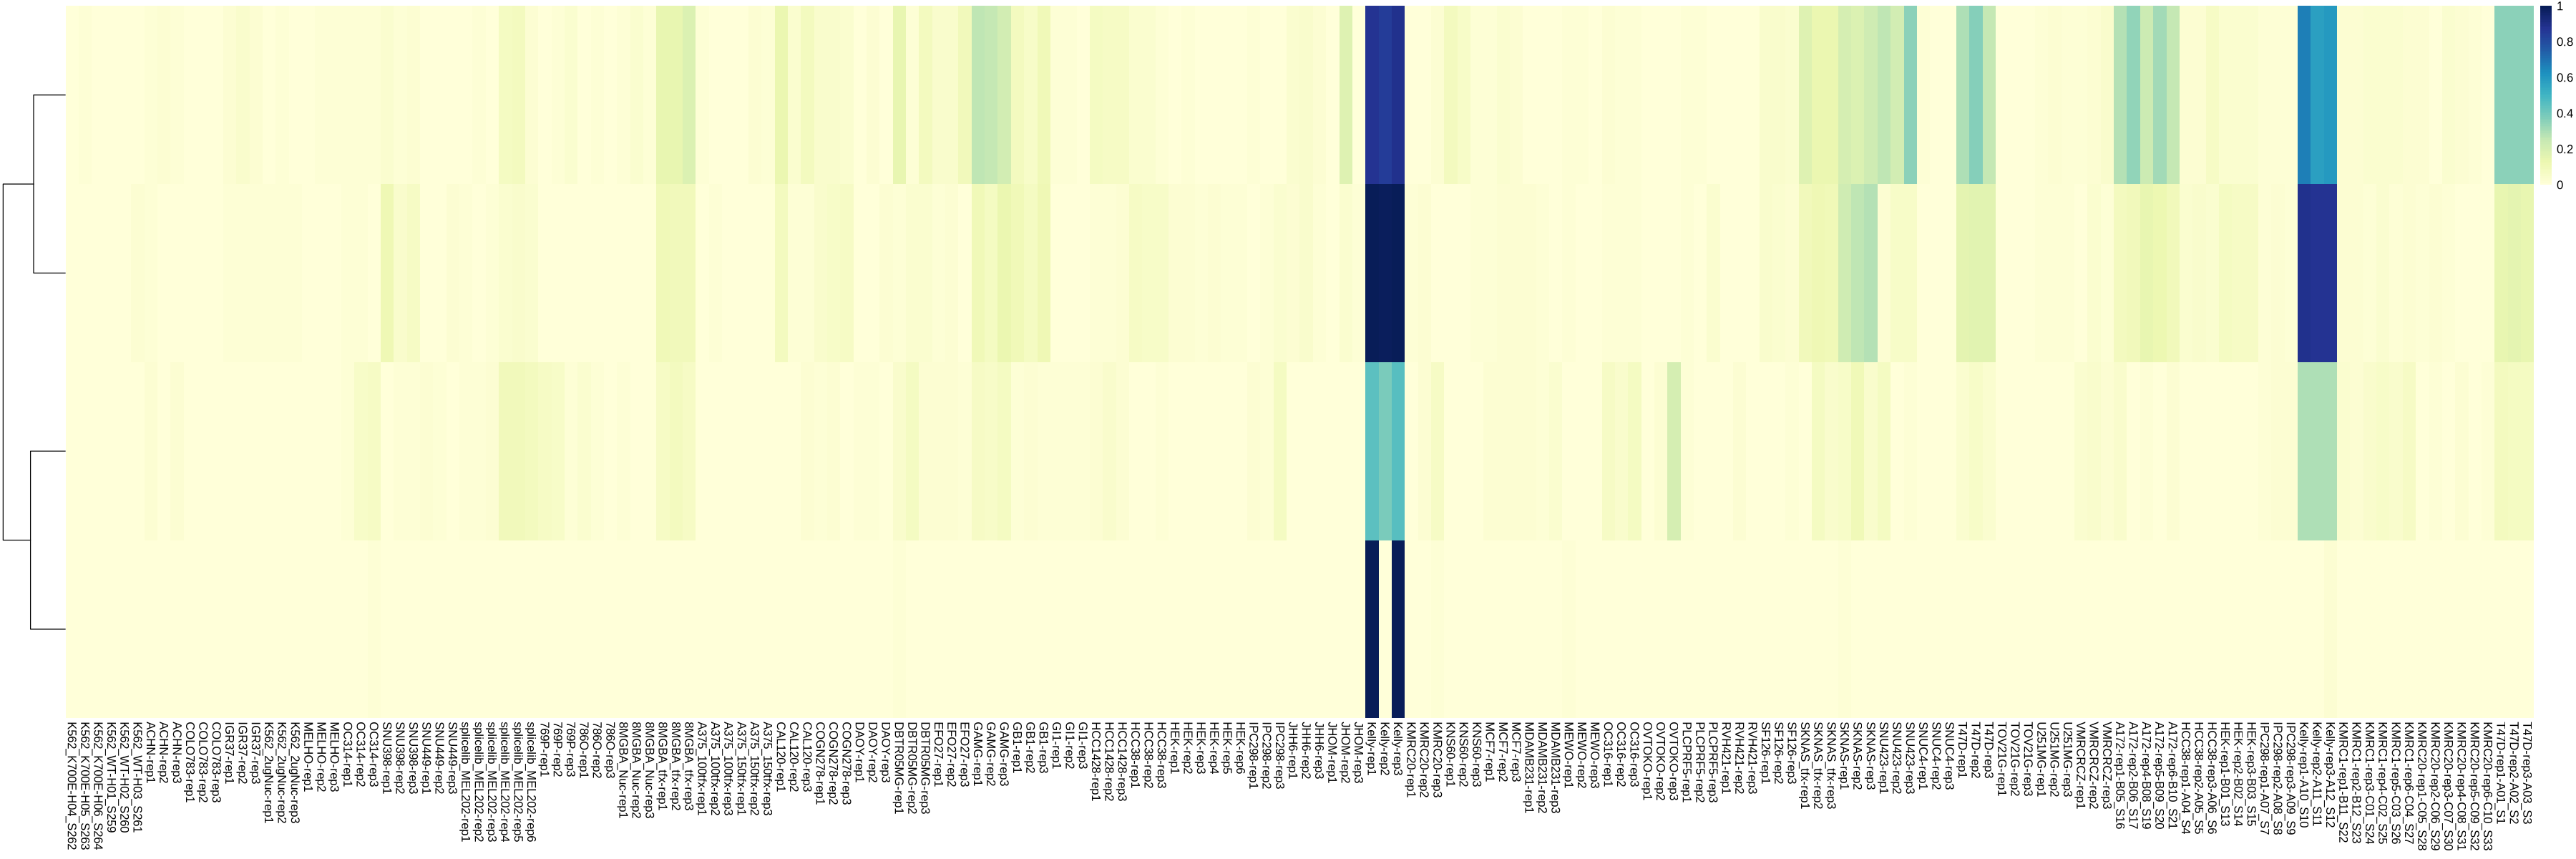

In [ ]:
top_index <- c("ENSG00000138821.14;SLC39A8;chr4-102285948-102285973-102267871-102268079-102304316-102304481",
"ENSG00000136717.15;BIN1;chr2-127053421-127053445-127051153-127051243-127053904-127054012",
"ENSG00000135365.16;PHF21A;chr11-45946075-45946098-45938156-45938312-45948885-45948946")

# First create the dataset
Kelly <- final_psi_table %>% 
  filter(index %in% top_index) %>% 
  mutate(PSI = included_count/(included_count + skipped_count)) %>% 
  mutate(index_offset = paste0(index, "__", offset))

# Create the pivot_wider table
Kelly <- Kelly %>%
  select(sample, index_offset, PSI) %>%
  pivot_wider(names_from = sample, values_from = PSI)
Kelly_heatmap <- Kelly %>% 
  column_to_rownames(var = "index_offset") %>% 
  as.matrix()

# Filter out rows that have > 50% NAs.
Kelly_heatmap <- Kelly_heatmap[rowMeans(is.na(Kelly_heatmap)) < 0.5, ]
# Set figure dimensions to make the heatmap larger
options(repr.plot.width=30, repr.plot.height=10)
pheatmap(Kelly_heatmap, 
         color = colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100),
         cluster_rows = TRUE, 
         cluster_cols = FALSE,
         show_colnames = TRUE,
         show_rownames = FALSE)


In [59]:
# MUT now.

all_files_df_path <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_raw_counts_individual.csv"
all_files_df <- fread(all_files_df_path)

# > head(all_files_df)
# index
# <char>
#   1: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 2: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 3: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 4: ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539
# 5: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# 6: ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252
# mode offset count count_scaled    sample condition
# <char> <char> <int>        <int>    <char>    <char>
#   1:  INCLUDED 0:-1:0     1            1 769P-rep1      769P
# 2:  INCLUDED  0:0:0    29           29 769P-rep1      769P
# 3:   SKIPPED      0     3            0 769P-rep1      769P
# 4: UNSPLICED    113     3            0 769P-rep1      769P
# 5:  INCLUDED  0:0:0    88           88 769P-rep1      769P
# 6:   SKIPPED      0    15            1 769P-rep1      769P

# First generate a set of all included events. 
all_files_df <- all_files_df %>% 
  group_by(sample,condition, index) %>%
  mutate(total_counts = sum(count_scaled),
         frac_of_total = count_scaled/total_counts) %>% 
  ungroup() %>% 
  # filter(total_counts >= 30) %>% 
  group_by(sample,condition, index, mode) %>%
  mutate(
    total_counts_per_mode = sum(count_scaled),
    frac_of_mode = count_scaled/sum(count_scaled)) %>% 
  ungroup() 



##### Now generate a set of all possible spliced events. #####
# First get a list of all possible perfect splicing events given all the barcodes. 
barcode_table <- read_csv("/mnt/dawnccle2/melange/data/guide_library_cleaned/20240605_twist_library_v3_ID_barcode_ROUT_filtered.csv")
all_perfect_events <- data.frame(index = barcode_table$ID, mode = "INCLUDED", offset = "0:0:0") %>% as_tibble()

# Imperfect events.
all_possible_imperfect_events <- all_files_df %>%
  filter(mode == "INCLUDED" & offset != "0:0:0" & total_counts_per_mode >= 30) %>% 
  group_by(index, mode, offset) %>% 
  summarise(n = n(), 
            max_perc = max(frac_of_mode), 
            max_reads = max(count_scaled),
            .groups = "drop" ) %>% 
  separate(offset, into = c("skipped_exon_start", "skipped_exon_end", "downstream_exon_start"), sep = ":", remove = FALSE) %>%
  filter(skipped_exon_start < 150 & skipped_exon_end < 150)

all_possible_imperfect_events_filtered <- all_possible_imperfect_events %>% 
  filter(max_reads >= 5 & max_perc > 0.01) %>% 
  select(index, mode, offset)

# All possible included events. 
all_possible_included_events <- rbind(all_perfect_events, all_possible_imperfect_events_filtered) %>% 
  arrange(index, mode, offset) 

# Now also find the set of all possible exon skipping events. This is just the barcode list. 
all_possible_skipped_events <- data.frame(index = barcode_table$ID, mode = "SKIPPED", offset = "0") %>% as_tibble()

# Now also find a set of all possible unspliced events. Probably this doesn't need to use the adjusted reads. 
all_possible_unspliced_events <- all_files_df %>% 
  filter(mode == "UNSPLICED" ) %>% 
  group_by(mode, offset) %>%
  summarise(n = n(), 
            max_perc = max(frac_of_mode, na.rm = T), 
            max_reads = max(count, na.rm = T),
            .groups = "drop" ) %>% 
  mutate(offset = as.integer(offset)) 

####### Now generate a PSI table for each event. #######
####### Now generate a PSI table for each event. #######
# Convert to data.table for faster lookups
all_files_df <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_raw_counts_individual.csv")
setDT(all_files_df)
setDT(all_possible_included_events)


all_files_df <- all_files_df %>% 
  mutate(sample_condition = paste0(sample, "__", condition))
unique_sample_conditions <- unique(all_files_df$sample_condition)


all_possible_included_events <- all_possible_included_events %>% 
mutate(index_offset = paste0(index, "__", offset))

# Expand grid for all_possible_included_events
expanded_events <- expand.grid(index_offset = all_possible_included_events$index_offset, 
                                sample_condition = unique_sample_conditions)


all_files_df_included <- all_files_df %>% 
filter(mode == "INCLUDED") %>% 
mutate(sample_condition = paste0(sample, "__", condition)) %>% 
mutate(index_offset = paste0(index, "__", offset)) %>% 
mutate(included_count = count_scaled) %>% 
select(sample_condition, index_offset, included_count)

all_files_df_skipped <- all_files_df %>% 
filter(mode == "SKIPPED") %>% 
mutate(sample_condition = paste0(sample, "__", condition)) %>% 
group_by(sample_condition, index) %>% 
summarise(skipped_count = sum(count_scaled)) %>% 
select(sample_condition, index, skipped_count)

final_psi_table <- expanded_events %>% 
left_join(all_files_df_included, by = c("sample_condition", "index_offset")) %>% 
# Set all NAs to 0.
mutate(included_count = ifelse(is.na(included_count), 0, included_count)) %>% 
separate(index_offset, into = c("index", "offset"), sep = "__", remove = FALSE) %>% 
left_join(all_files_df_skipped, by = c("sample_condition", "index")) %>% 
mutate(skipped_count = ifelse(is.na(skipped_count), 0, skipped_count)) 

# Separate the index_offset into index, offset, and sample_condition.
final_psi_table <- final_psi_table %>% 
separate(index_offset, into = c("index", "offset"), sep = "__") %>% 
separate(sample_condition, into = c("sample", "condition"), sep = "__") %>% 
mutate(mode = "INCLUDED")

# Write to file
fwrite(final_psi_table, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_PSI_count_table_individual.csv")

# Also filter to sequences that have total reads >= 30. 
final_psi_table_filtered <- final_psi_table %>% 
  mutate(total_reads = included_count + skipped_count) %>%
  filter(total_reads >= 30) 
fwrite(final_psi_table_filtered, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/MUT_all_samples_PSI_count_table_individual_filtered.csv")

Rows: 44648 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): ID, barcode, barcodeRevcomp

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_perc = max(frac_of_mode, na.rm = T)`.
ℹ In group 6: `mode = "UNSPLICED"` `offset = "103"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”
`summarise()` has grouped output by 'sample_condition'. You can override using
the `.groups` argument.


# Do again for WT. I just want to check if they are the same.

In [61]:
####### Now generate a PSI table for each event. #######
# Convert to data.table for faster lookups
all_files_df <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_raw_counts.csv")
all_possible_included_events <- read_csv("/mnt/dawnccle2/melange/process_fastq_250221/03_convert_to_PSI/WT_all_included_events.csv")
setDT(all_files_df)
setDT(all_possible_included_events)


all_files_df <- all_files_df %>% 
  mutate(sample_condition = paste0(sample, "__", condition))
unique_sample_conditions <- unique(all_files_df$sample_condition)


all_possible_included_events <- all_possible_included_events %>% 
mutate(index_offset = paste0(index, "__", offset))

# Expand grid for all_possible_included_events
expanded_events <- expand.grid(index_offset = all_possible_included_events$index_offset, 
                                sample_condition = unique_sample_conditions)


all_files_df_included <- all_files_df %>% 
filter(mode == "INCLUDED") %>% 
mutate(sample_condition = paste0(sample, "__", condition)) %>% 
mutate(index_offset = paste0(index, "__", offset)) %>% 
mutate(included_count = count_scaled) %>% 
select(sample_condition, index_offset, included_count)

all_files_df_skipped <- all_files_df %>% 
filter(mode == "SKIPPED") %>% 
mutate(sample_condition = paste0(sample, "__", condition)) %>% 
group_by(sample_condition, index) %>% 
summarise(skipped_count = sum(count_scaled)) %>% 
select(sample_condition, index, skipped_count)

final_psi_table <- expanded_events %>% 
left_join(all_files_df_included, by = c("sample_condition", "index_offset")) %>% 
# Set all NAs to 0.
mutate(included_count = ifelse(is.na(included_count), 0, included_count)) %>% 
separate(index_offset, into = c("index", "offset"), sep = "__", remove = FALSE) %>% 
left_join(all_files_df_skipped, by = c("sample_condition", "index")) %>% 
mutate(skipped_count = ifelse(is.na(skipped_count), 0, skipped_count)) 

# Separate the index_offset into index, offset, and sample_condition.
final_psi_table <- final_psi_table %>% 
separate(index_offset, into = c("index", "offset"), sep = "__") %>% 
separate(sample_condition, into = c("sample", "condition"), sep = "__") %>% 
mutate(mode = "INCLUDED")

# Write to file
fwrite(final_psi_table, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_V2.csv")

# Also filter to sequences that have total reads >= 30. 
final_psi_table_filtered <- final_psi_table %>% 
  mutate(total_reads = included_count + skipped_count) %>%
  filter(total_reads >= 30) 
fwrite(final_psi_table_filtered, "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_individual_V2_filtered.csv")

Rows: 63034 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): index, mode, offset

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'sample_condition'. You can override using
the `.groups` argument.


In [75]:
final_psi_table_filtered_V1 <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_filtered.csv")
final_psi_table_filtered_V2 <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_v4_merged/WT_all_samples_PSI_count_table_individual_V2_filtered.csv")

final_psi_table_filtered_V1 <- final_psi_table_filtered_V1 %>% 
arrange(index, offset, sample, condition) %>% 
select(index, offset, sample, condition, included_count, skipped_count)

final_psi_table_filtered_V2 <- final_psi_table_filtered_V2 %>% 
arrange(index, offset, sample, condition) %>% 
select(index, offset, sample, condition, included_count, skipped_count)


all.equal(final_psi_table_filtered_V1, final_psi_table_filtered_V2)

[1] TRUE

[1] TRUE

In [72]:
head(final_psi_table_filtered_V2 %>% arrange(index, offset, sample, condition))

index,offset,sample,condition,included_count,skipped_count,mode,total_reads
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,0:0:0,769P-rep2,769P,47,0,INCLUDED,47
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,0:0:0,769P-rep3,769P,40,2,INCLUDED,42
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,0:0:0,786O-rep1,786O,49,0,INCLUDED,49
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,0:0:0,786O-rep2,786O,43,0,INCLUDED,43
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,0:0:0,786O-rep3,786O,38,1,INCLUDED,39
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,0:0:0,8MGBA-rep1,8MGBA,112,5,INCLUDED,117
